<a href="https://colab.research.google.com/github/davidbacavidal/Kaggle-competitions/blob/main/22_06_2026_Forecasting_Sticker_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [9]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

playground_series_s5e1_path = kagglehub.competition_download('playground-series-s5e1')

print('Data source import complete.')

Data source import complete.


In [10]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Packages and data initialization

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
color_pal = sns.color_palette()

In [12]:
import os
# DataFrame with training data
train_df = pd.read_csv(os.path.join(playground_series_s5e1_path, 'train.csv'), parse_dates=["date"])
train_df.head()

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [13]:
# DataFrame with testing data
test_df = pd.read_csv(os.path.join(playground_series_s5e1_path, 'test.csv'), parse_dates=["date"])
test_df.head()

,id,date,country,store,product
0,230130,2017-01-01,Canada,Discount Stickers,Holographic Goose
1,230131,2017-01-01,Canada,Discount Stickers,Kaggle
2,230132,2017-01-01,Canada,Discount Stickers,Kaggle Tiers
3,230133,2017-01-01,Canada,Discount Stickers,Kerneler
4,230134,2017-01-01,Canada,Discount Stickers,Kerneler Dark Mode


In [14]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    return df

# Data analysis

In [15]:
#Type of variables
train_df.dtypes

,0
id,int64
date,datetime64[ns]
country,object
store,object
product,object
num_sold,float64


Three variables type object, one type date time. Dependent variable type numeric

In [ ]:
train_df["country"].unique()

array(['Canada', 'Finland', 'Italy', 'Kenya', 'Norway', 'Singapore'],
      dtype=object)

In [ ]:
train_df["store"].unique()

array(['Discount Stickers', 'Stickers for Less', 'Premium Sticker Mart'],
      dtype=object)

In [ ]:
train_df["product"].unique()

array(['Holographic Goose', 'Kaggle', 'Kaggle Tiers', 'Kerneler',
       'Kerneler Dark Mode'], dtype=object)

The variables country, store and product are categorical nominal variables.

The variable country has 6 levels, store has 3 levels and product has 5 levels

# Outliers

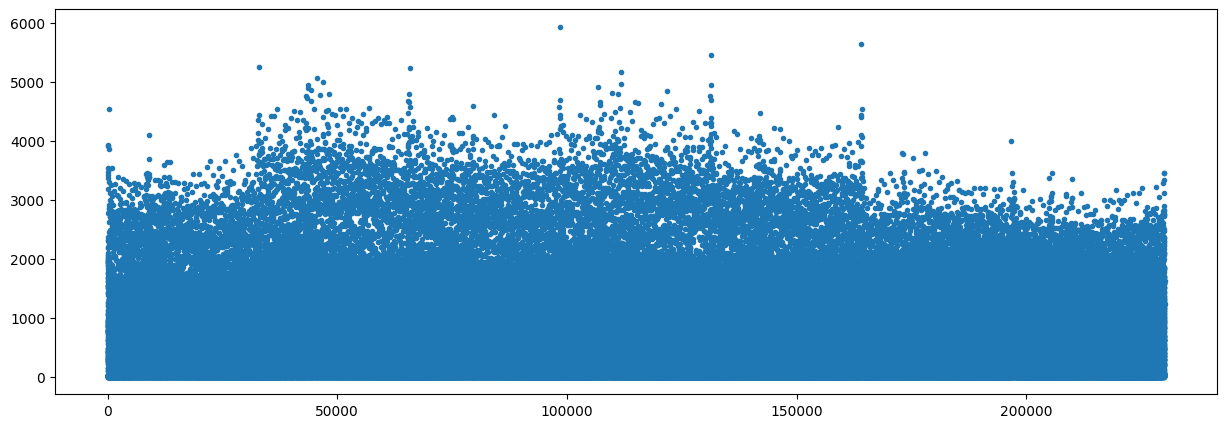

In [20]:
train_df.num_sold.plot(style='.',
             figsize=(15,5),
             color=color_pal[0])
plt.show()

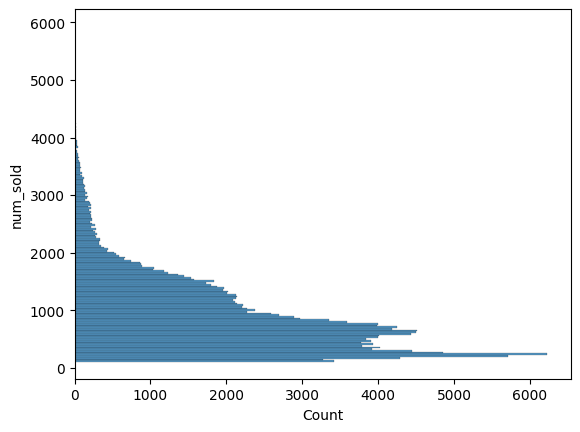

In [26]:
sns.histplot(data=train_df[train_df["num_sold"]>100], y="num_sold")
plt.show()

# DATA transformation

In [ ]:

# Función para agregar lags
def add_lags(df):
    """
    Agrega características de lag a un DataFrame de ventas.
    """
    # Asegúrate de que el DataFrame esté ordenado por fecha
    df = df.sort_values(by=['country', 'store', 'product', 'date'])

    # Crear un diccionario que mapea las fechas a 'num_sold'
    target_map = df.set_index(['country', 'store', 'product', 'date'])['num_sold'].to_dict()

    # Crear lags
    df['lag1'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=1)), None)
    )
    df['lag2'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=2)), None)
    )
    df['lag3'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=3)), None)
    )
    df['lag4'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=4)), None)
    )
    df['lag5'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=5)), None)
    )
    df['lag6'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=6)), None)
    )
    df['lag7'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=7)), None)
    )
    df['lag8'] = df.set_index(['country', 'store', 'product', 'date']).index.map(
        lambda x: target_map.get((x[0], x[1], x[2], x[3] - pd.DateOffset(years=8)), None)
    )

    return df

In [ ]:
#Create a new column to differentiate the two dataFrame and join them
train_df['isFuture'] = False
test_df['isFuture'] = True
df_merged = pd.concat([train_df, test_df])

df_merged['Time'] = df_merged.groupby(['country', 'store', 'product']).cumcount() #time-step feature
df_merged['lag1day'] = df_merged.groupby(['country', 'store', 'product'])['num_sold'].shift(1)  # 1 day lag

df_merged = create_features(df_merged)

df_merged = add_lags(df_merged)
df_merged

In [ ]:
# making sure everything is allright
filtered_data=df_merged.copy()
filtered_data = filtered_data[
(filtered_data['country']=='Canada')&
(filtered_data['store']=="Discount Stickers") &
(filtered_data['product']=='Kaggle') &
(filtered_data['dayofyear'].isin([1,2,3,4]))]
columns_to_display = ['date','Time','num_sold', 'lag1day', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8']
filtered_data = filtered_data[columns_to_display]
filtered_data

In [ ]:
df_merged.columns

In [ ]:
# set variable y and x for the training data
df_merged=df_merged.sort_values(by='id')
y_train = df_merged[df_merged['isFuture']==False].num_sold

In [ ]:

train_df_features = ['id','isFuture','country', 'store',
                     'product','Time', 'lag1day',
                     'dayofweek', 'quarter',
                     'month','year', 'dayofyear',
                     'dayofmonth','weekofyear', 'lag1',
                     'lag2', 'lag3','lag4', 'lag5', 'lag6',
                     'lag7', 'lag8']

df_x = df_merged[train_df_features]

In [ ]:
# See which columns are type categorical and store them
s = (df_x.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)

In [ ]:
#Transforming the categorical variables from the test and training data into numerical
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
OH_cols_df = pd.DataFrame(OH_encoder.fit_transform(df_x[object_cols]))


In [ ]:
OH_cols_df.index = df_x.index

num_x_df = df_x.drop(object_cols, axis=1)

OH_x_df = pd.concat([num_x_df, OH_cols_df], axis=1)

OH_x_df.columns = OH_x_df.columns.astype(str)


In [ ]:
# Solve the NAs problems on X data
OH_x_df=OH_x_df.fillna(0)

#view the data
filtered_data2=OH_x_df.copy()
filtered_data2 = filtered_data2[
(filtered_data2['id'].isin([1,91,181,271]))]
columns_to_display = ['Time','lag1day', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'lag8']
filtered_data2 = filtered_data2[columns_to_display]
filtered_data2

In [ ]:
from sklearn.impute import SimpleImputer

# Make a copy of the original Y set
y_train_plus = y_train.copy()

# Creat new columns for the missing values
y_train_plus = y_train_plus.to_frame()  # Pass into a DataFrame
y_train_plus['num_sold_was_missing'] = y_train_plus['num_sold'].isnull()

# Select only the numerical columns for imputation
imputer = SimpleImputer()
imputed_values = imputer.fit_transform(y_train_plus[['num_sold']])

# Rebuild the DataFrame with imputated values
imputed_y_train_plus = pd.DataFrame(imputed_values, columns=['num_sold'], index=y_train_plus.index)

# Add the columns with the missing values
imputed_y_train_plus['num_sold_was_missing'] = y_train_plus['num_sold_was_missing']
# Delete the column 'num_sold_was_missing'
imputed_y_train_plus = imputed_y_train_plus.drop(columns=['num_sold_was_missing'])
imputed_y_train_plus = pd.DataFrame(imputed_y_train_plus)
imputed_y_train_plus.describe()

In [ ]:
#Make sure there isn't no NAs
print(imputed_y_train_plus.isnull().sum())  # It should be 0
imputed_y_train_plus.head()

In [ ]:
print(OH_x_df.isnull().sum())  # It should be 0


In [ ]:
OH_x_df.columns

In [ ]:
imputed_x_train_plus = OH_x_df[OH_x_df['isFuture']==False].drop(['id', 'isFuture'], axis=1)
imputed_x_test_plus = OH_x_df[OH_x_df['isFuture']==True].drop(['id', 'isFuture'], axis=1)

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.model_selection import train_test_split


# Definir el modelo
model = XGBRegressor()

# Definir la cuadrícula de parámetros
#param_grid = {
#   'learning_rate': [0.2,0.3,0.4],
#    'max_depth': [8,9,10],
#    'gamma': [0,0.25],
#    'reg_lambda': [0,1.0],
#    'scale_pos_weight': [1,3],
#    'n_estimators': [100,200],

#}

#param_grid = {
#   'learning_rate': [0.1,0.2],
#    'max_depth': [10,11,12],
#    'gamma': [0.25, 0.5],
#    'reg_lambda': [1.0,2.0],
#    'scale_pos_weight': [1],
#    'n_estimators': [50,100],
#}

#param_grid = {
#   'learning_rate': [0.1],
#    'max_depth': [12, 13, 14],
#    'gamma': [0.25],
#    'reg_lambda': [2.0, 3.0, 4.0],
#    'scale_pos_weight': [1],
#    'n_estimators': [100],
#}
#param_grid = {
 #  'learning_rate': [0.1],
#    'max_depth': [12],
#    'gamma': [0.25],
#    'reg_lambda': [3.0],
#    'scale_pos_weight': [1],
#    'n_estimators': [100],
#}
#X_train, X_valid, y_train, y_valid = train_test_split(imputed_x_train_plus, imputed_y_train_plus, test_size=0.2, random_state=42)

# Configurar la validación cruzada
#kfold = KFold(n_splits=10, shuffle=True, random_state=7)

# Configurar la búsqueda en cuadrícula
#grid_search = GridSearchCV(model, param_grid, scoring="neg_mean_absolute_error", n_jobs=-1, cv=kfold)

# Ajustar el modelo
#grid_result = grid_search.fit(imputed_x_train_plus, imputed_y_train_plus.num_sold,
#             early_stopping_rounds=5,
#             eval_set=[(X_valid, y_valid)],
#             verbose=False)

# Resumir resultados
#print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
#means = grid_result.cv_results_['mean_test_score']
#stds = grid_result.cv_results_['std_test_score']
#params = grid_result.cv_results_['params']
#for mean, stdev, param in zip(means, stds, params):
#    print("%f (%f) with: %r" % (mean, stdev, param))

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Supongamos que tienes tus datos en X e y
X_train, X_valid, y_train, y_valid = train_test_split(imputed_x_train_plus, imputed_y_train_plus, test_size=0.2, random_state=42)


#Fit the model
from xgboost import XGBRegressor

StickerModel = XGBRegressor(
    learning_rate=0.1,
    max_depth=12,
    gamma=0.25,
    reg_lambda=3.0,
    scale_pos_weight=1,
    n_estimators=100,
    random_state=42
)
StickerModel.fit(imputed_x_train_plus, imputed_y_train_plus.num_sold,
             early_stopping_rounds=5,
             eval_set=[(X_valid, y_valid)],
             verbose=False)



In [ ]:
predictions = StickerModel.predict(imputed_x_test_plus)
print(predictions.shape)

In [ ]:
test_df_copy = pd.DataFrame(test_df.copy())
test_df_copy['num_sold'] = StickerModel.predict(imputed_x_test_plus)

In [ ]:
test_df_copy[['id', 'num_sold']].to_csv('Forecasting_Sticker_sale9', index=False)

In [ ]:
df_merged.columns

In [ ]:
columns_lag=['lag1', 'lag2', 'lag3', 'lag4', 'lag5',
       'lag6', 'lag7', 'lag8']
col_im= imputed_x_train_plus.columns

In [ ]:
fi2 = pd.DataFrame(data=StickerModel.feature_importances_,
             index=StickerModel.feature_names_in_,
             columns=['columns_lag'])
fi2.sort_values('columns_lag').plot(kind='barh', title='Feature Importance')
plt.show()

In [ ]:
y_predic= StickerModel.predict(X_valid)
print(y_predic.shape,y_valid['num_sold'].shape)

In [ ]:
print("fin de proceso")

epa
